# Validation 3: $M_{\mathrm{hom}}$ vs $M_{\mathrm{het}}$ across sample size

This notebook visualises the completed synthetic model-comparison run produced by `section_3/script/run_3_bf_homVShet.sh`. It compares the two history-dependent models that differ only in decision-level heterogeneity:

- $M_{\mathrm{hom}}$: homogeneous history-dependent model ($\sigma_\eta=0$)
- $M_{\mathrm{het}}$: heterogeneous history-dependent model ($\sigma_\eta$ is estimated)

For every scenario, replicate, and sample size, the plotted contrast is

$$
\log_{10}\mathrm{BF}(M_{\mathrm{hom}}/M_{\mathrm{het}})
= \frac{\log p(D\mid M_{\mathrm{hom}})-\log p(D\mid M_{\mathrm{het}})}{\log 10}.
$$

Positive values favour $M_{\mathrm{hom}}$; negative values favour $M_{\mathrm{het}}$. Thin lines are the five independent simulation replicates. The thick line and error bars show the replicate mean $\pm$ one standard deviation. Sample-size subsets are nested within each replicate, so their points are connected as trajectories.


In [2]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import NullLocator
from IPython.display import display
import scienceplots
plt.style.use(["science"])

try:
    import scienceplots

    plt.style.use(["science", "no-latex"])
except ModuleNotFoundError:
    plt.style.use("default")


NOTEBOOK_CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        candidate
        for candidate in [NOTEBOOK_CWD, *NOTEBOOK_CWD.parents]
        if (candidate / "section_3" / "script" / "run_3_bf_homVShet.sh").exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the Barracuda project root from the current directory.")

RUN_LABEL = "homogeneous_vs_heterogeneous_hd_seed309"
RESULT_ROOT = (
    PROJECT_ROOT
    / "section_3"
    / "results"
    / "part_2_bf_homogeneous_vs_heterogeneous"
    / RUN_LABEL
)
FIGURE_ROOT = (
    PROJECT_ROOT
    / "section_3"
    / "figures"
    / "part_2_bf_homogeneous_vs_heterogeneous"
)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

SUMMARY_PATH = RESULT_ROOT / "logml_summary.csv"
CONFIG_PATH = RESULT_ROOT / "run_config.json"
PAIRWISE_PATH = RESULT_ROOT / "pairwise_bayes_factors.csv"

for required_path in (SUMMARY_PATH, CONFIG_PATH):
    if not required_path.exists():
        raise FileNotFoundError(f"Missing required result file: {required_path}")

logml_df = pd.read_csv(SUMMARY_PATH)
run_config = json.loads(CONFIG_PATH.read_text())
pd.set_option("display.max_columns", 100)

print(f"Loaded {len(logml_df):,} evidence rows from {SUMMARY_PATH}")
print(f"Configured sample sizes: {run_config['sample_sizes']}")
print(f"Configured replicates: {run_config['replicates']}")


Loaded 140 evidence rows from /Users/marsian/PhD_LifeSciRes/Barracuda/section_3/results/part_2_bf_homogeneous_vs_heterogeneous/homogeneous_vs_heterogeneous_hd_seed309/logml_summary.csv
Configured sample sizes: [10, 20, 50, 100, 200, 500, 1000]
Configured replicates: 5


## Validate and calculate the pairwise Bayes factor

The top-level `logml_summary.csv` and `run_config.json` define the completed balanced experiment. The checks below deliberately reject duplicate fits, missing model pairs, non-finite evidence, or a sample-size/replicate grid that disagrees with the saved configuration. This avoids silently mixing in incomplete exploratory result directories.


In [3]:
HOM_MODEL = "homogeneous_history_dependent"
HET_MODEL = "heterogeneous_history_dependent"
REQUIRED_MODELS = {HOM_MODEL, HET_MODEL}

required_columns = {
    "scenario",
    "scenario_label",
    "replicate",
    "simulation_seed",
    "n_cells",
    "gt_mean_lambda",
    "gt_sigma_lambda",
    "gt_p0",
    "gt_sigma_eta",
    "gt_beta_x",
    "gt_beta_y",
    "true_model",
    "model",
    "logml",
}
missing_columns = required_columns.difference(logml_df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

pair = logml_df[logml_df["model"].isin(REQUIRED_MODELS)].copy()
observed_models = set(pair["model"].astype(str))
if observed_models != REQUIRED_MODELS:
    raise ValueError(f"Expected models {sorted(REQUIRED_MODELS)}, found {sorted(observed_models)}")
if not np.isfinite(pair["logml"].to_numpy(dtype=float)).all():
    raise ValueError("All log marginal likelihoods must be finite.")

dataset_columns = ["scenario", "replicate", "n_cells"]
duplicate_counts = pair.groupby([*dataset_columns, "model"], dropna=False).size()
duplicate_counts = duplicate_counts[duplicate_counts != 1]
if not duplicate_counts.empty:
    raise ValueError(f"Expected one row per dataset/model; invalid groups: {duplicate_counts.to_dict()}")

model_coverage = pair.groupby(dataset_columns, dropna=False)["model"].agg(set)
incomplete = model_coverage[model_coverage.map(lambda models: models != REQUIRED_MODELS)]
if not incomplete.empty:
    raise ValueError(f"Missing a model in dataset groups: {incomplete.to_dict()}")

metadata_columns = [
    "scenario_label",
    "simulation_seed",
    "gt_mean_lambda",
    "gt_sigma_lambda",
    "gt_p0",
    "gt_sigma_eta",
    "gt_beta_x",
    "gt_beta_y",
    "true_model",
]
metadata_consistency = pair.groupby(dataset_columns, dropna=False)[metadata_columns].nunique(dropna=False)
inconsistent_metadata = metadata_consistency[(metadata_consistency > 1).any(axis=1)]
if not inconsistent_metadata.empty:
    raise ValueError(f"Model rows disagree on dataset metadata: {inconsistent_metadata.index.tolist()}")

metadata = pair.groupby(dataset_columns, as_index=False, dropna=False)[metadata_columns].first()
evidence = (
    pair.pivot(index=dataset_columns, columns="model", values="logml")
    .reset_index()
    .rename_axis(columns=None)
    .rename(
        columns={
            HOM_MODEL: "logml_homogeneous_history_dependent",
            HET_MODEL: "logml_heterogeneous_history_dependent",
        }
    )
)
pairwise_df = metadata.merge(evidence, on=dataset_columns, how="inner", validate="one_to_one")

log_bf_hom_vs_het = (
    pairwise_df["logml_homogeneous_history_dependent"]
    - pairwise_df["logml_heterogeneous_history_dependent"]
)
pairwise_df["log_bf_homogeneous_vs_heterogeneous"] = log_bf_hom_vs_het
pairwise_df["log10_bf_homogeneous_vs_heterogeneous"] = log_bf_hom_vs_het / np.log(10.0)
pairwise_df["log_bf_heterogeneous_vs_homogeneous"] = -log_bf_hom_vs_het
pairwise_df["log10_bf_heterogeneous_vs_homogeneous"] = -log_bf_hom_vs_het / np.log(10.0)
pairwise_df["best_selected_model"] = np.select(
    [log_bf_hom_vs_het > 0, log_bf_hom_vs_het < 0],
    [HOM_MODEL, HET_MODEL],
    default="tie",
)
pairwise_df["correct_selection"] = pairwise_df["best_selected_model"].eq(pairwise_df["true_model"])
pairwise_df["log10_bf_true_vs_alternative"] = np.where(
    pairwise_df["true_model"].eq(HOM_MODEL),
    pairwise_df["log10_bf_homogeneous_vs_heterogeneous"],
    pairwise_df["log10_bf_heterogeneous_vs_homogeneous"],
)

configured_sizes = sorted({int(value) for value in run_config["sample_sizes"]})
observed_sizes = sorted(pairwise_df["n_cells"].astype(int).unique().tolist())
if observed_sizes != configured_sizes:
    raise ValueError(f"Summary sample sizes {observed_sizes} disagree with run_config {configured_sizes}.")

expected_replicates = int(run_config["replicates"])
replicate_coverage = pairwise_df.groupby(["scenario", "n_cells"])["replicate"].nunique()
if not replicate_coverage.eq(expected_replicates).all():
    raise ValueError(f"Incomplete replicate grid: {replicate_coverage.to_dict()}")

pairwise_df = pairwise_df.sort_values(["scenario", "replicate", "n_cells"]).reset_index(drop=True)
pairwise_df.to_csv(PAIRWISE_PATH, index=False)
print(f"Validated {len(pairwise_df)} paired comparisons and saved {PAIRWISE_PATH}")
pairwise_df.head()


Validated 70 paired comparisons and saved /Users/marsian/PhD_LifeSciRes/Barracuda/section_3/results/part_2_bf_homogeneous_vs_heterogeneous/homogeneous_vs_heterogeneous_hd_seed309/pairwise_bayes_factors.csv


,scenario,replicate,n_cells,scenario_label,simulation_seed,gt_mean_lambda,gt_sigma_lambda,gt_p0,gt_sigma_eta,gt_beta_x,gt_beta_y,true_model,logml_heterogeneous_history_dependent,logml_homogeneous_history_dependent,log_bf_homogeneous_vs_heterogeneous,log10_bf_homogeneous_vs_heterogeneous,log_bf_heterogeneous_vs_homogeneous,log10_bf_heterogeneous_vs_homogeneous,best_selected_model,correct_selection,log10_bf_true_vs_alternative
0,No1,1,10,"No1: sigma_eta=0.75, beta=(0.8,-0.8)",10310,4.0,2.0,0.25,0.75,0.8,-0.8,heterogeneous_history_dependent,-59.836511,-60.022600,-0.186089,-0.080818,0.186089,0.080818,heterogeneous_history_dependent,True,0.080818
1,No1,1,20,"No1: sigma_eta=0.75, beta=(0.8,-0.8)",10310,4.0,2.0,0.25,0.75,0.8,-0.8,heterogeneous_history_dependent,-106.338625,-106.281566,0.057059,0.024780,-0.057059,-0.024780,homogeneous_history_dependent,False,-0.024780
2,No1,1,50,"No1: sigma_eta=0.75, beta=(0.8,-0.8)",10310,4.0,2.0,0.25,0.75,0.8,-0.8,heterogeneous_history_dependent,-266.141091,-266.027009,0.114082,0.049545,-0.114082,-0.049545,homogeneous_history_dependent,False,-0.049545
3,No1,1,100,"No1: sigma_eta=0.75, beta=(0.8,-0.8)",10310,4.0,2.0,0.25,0.75,0.8,-0.8,heterogeneous_history_dependent,-531.736823,-531.720732,0.016091,0.006988,-0.016091,-0.006988,homogeneous_history_dependent,False,-0.006988
4,No1,1,200,"No1: sigma_eta=0.75, beta=(0.8,-0.8)",10310,4.0,2.0,0.25,0.75,0.8,-0.8,heterogeneous_history_dependent,-1018.240949,-1018.296469,-0.055520,-0.024112,0.055520,0.024112,heterogeneous_history_dependent,True,0.024112


## Replicate summary

The numerical table reports the mean and standard deviation in $\log_{10}$-BF space, together with the fraction of replicates that selected the generating model at each sample size.


In [4]:
BF_COLUMN = "log10_bf_homogeneous_vs_heterogeneous"

trajectory_summary = (
    pairwise_df.groupby(["scenario", "n_cells"], as_index=False)
    .agg(
        mean_log10_bf_hom_vs_het=(BF_COLUMN, "mean"),
        sd_log10_bf_hom_vs_het=(BF_COLUMN, "std"),
        median_log10_bf_hom_vs_het=(BF_COLUMN, "median"),
        min_log10_bf_hom_vs_het=(BF_COLUMN, "min"),
        max_log10_bf_hom_vs_het=(BF_COLUMN, "max"),
        fraction_correct=("correct_selection", "mean"),
        n_replicates=("replicate", "nunique"),
    )
    .sort_values(["scenario", "n_cells"])
)

quality_control = (
    pairwise_df.groupby("scenario", as_index=False)
    .agg(
        true_model=("true_model", "first"),
        sigma_eta=("gt_sigma_eta", "first"),
        n_sample_sizes=("n_cells", "nunique"),
        n_replicates=("replicate", "nunique"),
        n_pairs=(BF_COLUMN, "size"),
    )
)
display(quality_control)
display(trajectory_summary.round(3))


,scenario,true_model,sigma_eta,n_sample_sizes,n_replicates,n_pairs
0,No1,heterogeneous_history_dependent,0.75,7,5,35
1,No3,homogeneous_history_dependent,0.00,7,5,35


,scenario,n_cells,mean_log10_bf_hom_vs_het,sd_log10_bf_hom_vs_het,median_log10_bf_hom_vs_het,min_log10_bf_hom_vs_het,max_log10_bf_hom_vs_het,fraction_correct,n_replicates
0,No1,10,-0.036,0.194,-0.081,-0.225,0.171,0.6,5
1,No1,20,-0.122,0.275,-0.016,-0.511,0.181,0.6,5
2,No1,50,-0.082,0.414,0.050,-0.692,0.362,0.4,5
3,No1,100,-0.169,0.482,-0.044,-1.003,0.245,0.6,5
4,No1,200,-0.657,0.710,-0.336,-1.719,-0.024,1.0,5
5,No1,500,-0.966,0.460,-1.126,-1.360,-0.312,1.0,5
6,No1,1000,-1.807,1.249,-2.399,-2.939,0.173,0.8,5
7,No3,10,0.230,0.140,0.249,-0.007,0.345,0.8,5
8,No3,20,0.118,0.168,0.130,-0.095,0.369,0.8,5
9,No3,50,0.058,0.111,0.083,-0.106,0.159,0.8,5


## Bayes-factor trajectories

The background bands use conventional BF thresholds of 3, 10, and 100. The sign identifies which model is supported; the magnitude identifies evidence strength.


In [5]:
HOM_COLOR = "#3B6FB6"
HET_COLOR = "#C75B39"
SCENARIO_ROMAN = {"No1": "i", "No2": "ii", "No3": "iii", "No4": "iv"}
BAND_COLORS = {
    "anecdotal": "#F7F7F7",
    "moderate": "#FFF3B0",
    "strong": "#FFD28A",
    "extreme": "#E76F51",
}


def scenario_title(row: pd.Series) -> str:
    scenario_id = str(row["scenario"])
    roman = SCENARIO_ROMAN.get(scenario_id, scenario_id)
    true_label = "Homogeneous truth" if str(row["true_model"]) == HOM_MODEL else "Heterogeneous truth"
    return rf"({roman}) {true_label} ($\sigma_\eta={float(row['gt_sigma_eta']):g}$)"


def add_evidence_bands(ax, *, limit: float, show_labels: bool = False) -> None:
    bf3 = np.log10(3.0)
    ax.axhspan(-bf3, bf3, color=BAND_COLORS["anecdotal"], alpha=0.95, linewidth=0, zorder=0)

    regions = [
        (bf3, 1.0, "moderate"),
        (1.0, 2.0, "strong"),
        (2.0, limit, "extreme"),
    ]
    for low, high, label in regions:
        if low >= limit:
            continue
        visible_high = min(high, limit)
        ax.axhspan(low, visible_high, color=BAND_COLORS[label], alpha=0.27, linewidth=0, zorder=0)
        ax.axhspan(-visible_high, -low, color=BAND_COLORS[label], alpha=0.27, linewidth=0, zorder=0)
        if show_labels:
            for y in ((low + visible_high) / 2, -(low + visible_high) / 2):
                ax.text(
                    0.985,
                    y,
                    label.capitalize(),
                    transform=ax.get_yaxis_transform(),
                    ha="right",
                    va="center",
                    fontsize=9,
                    color="0.25",
                    alpha=0.75,
                    zorder=1,
                )

    for value in (-2.0, -1.0, -bf3, 0.0, bf3, 1.0, 2.0):
        if -limit <= value <= limit:
            ax.axhline(
                value,
                color="black",
                linestyle="--" if value == 0.0 else ":",
                linewidth=1.35 if value == 0.0 else 0.8,
                alpha=0.8 if value == 0.0 else 0.42,
                zorder=1,
            )


def plot_pairwise_bf_trajectories(
    data: pd.DataFrame,
    *,
    y_limit: float = 3.2,
    figsize: tuple[float, float] = (12.5, 5.2),
    dpi: int = 300,
):
    configured_scenarios = [str(value) for value in run_config.get("scenarios", [])]
    present = set(data["scenario"].astype(str))
    scenarios = [scenario for scenario in configured_scenarios if scenario in present]
    scenarios.extend(sorted(present.difference(scenarios)))
    if not scenarios:
        raise ValueError("No scenarios available to plot.")

    fig, axes = plt.subplots(
        1,
        len(scenarios),
        figsize=figsize,
        dpi=dpi,
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes = axes.ravel()
    sample_sizes = sorted(data["n_cells"].astype(int).unique().tolist())

    for panel_index, (ax, scenario_id) in enumerate(zip(axes, scenarios)):
        sub = data[data["scenario"].astype(str) == scenario_id].copy()
        info = sub.iloc[0]
        true_is_homogeneous = str(info["true_model"]) == HOM_MODEL
        color = HOM_COLOR if true_is_homogeneous else HET_COLOR
        add_evidence_bands(ax, limit=y_limit, show_labels=panel_index == len(scenarios) - 1)

        for _replicate, replicate_df in sub.groupby("replicate"):
            replicate_df = replicate_df.sort_values("n_cells")
            ax.plot(
                replicate_df["n_cells"],
                replicate_df[BF_COLUMN],
                color=color,
                linewidth=1.15,
                marker="o",
                markersize=3.0,
                alpha=0.22,
                zorder=2,
            )

        summary = (
            sub.groupby("n_cells", as_index=False)[BF_COLUMN]
            .agg(mean="mean", sd="std")
            .sort_values("n_cells")
        )
        summary["sd"] = summary["sd"].fillna(0.0)
        ax.errorbar(
            summary["n_cells"],
            summary["mean"],
            yerr=summary["sd"],
            color=color,
            linewidth=2.6,
            marker="o",
            markersize=6.0,
            markeredgecolor="white",
            markeredgewidth=0.8,
            capsize=4.0,
            elinewidth=1.45,
            capthick=1.3,
            zorder=4,
        )

        ax.set_xscale("log")
        ax.set_xticks(sample_sizes)
        ax.set_xticklabels([str(value) for value in sample_sizes])
        ax.xaxis.set_minor_locator(NullLocator())
        ax.yaxis.set_minor_locator(NullLocator())
        ax.set_ylim(-y_limit, y_limit)
        ax.set_yticks(np.arange(-3, 4, 1))
        ax.set_title(scenario_title(info), fontsize=15, pad=10)
        ax.set_xlabel("Number of in-silico NK cells", fontsize=13)
        ax.tick_params(axis="both", which="major", labelsize=11)
        ax.grid(False)

        ax.text(
            0.02,
            0.97,
            r"$\uparrow$ supports $M_{\mathrm{hom}}$",
            transform=ax.transAxes,
            color=HOM_COLOR,
            fontsize=10,
            ha="left",
            va="top",
        )
        ax.text(
            0.02,
            0.03,
            r"$\downarrow$ supports $M_{\mathrm{het}}$",
            transform=ax.transAxes,
            color=HET_COLOR,
            fontsize=10,
            ha="left",
            va="bottom",
        )

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)
            spine.set_color("black")

    axes[0].set_ylabel(
        r"$\log_{10}\mathrm{BF}(M_{\mathrm{hom}}/M_{\mathrm{het}})$",
        fontsize=14,
    )
    legend_handles = [
        Line2D([0], [0], color="0.35", linewidth=1.2, marker="o", markersize=3, alpha=0.35, label="Individual replicate"),
        Line2D([0], [0], color="0.15", linewidth=2.6, marker="o", markersize=6, label=r"Replicate mean $\pm$ SD"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.01),
        ncol=2,
        frameon=False,
        fontsize=11,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    return fig, axes


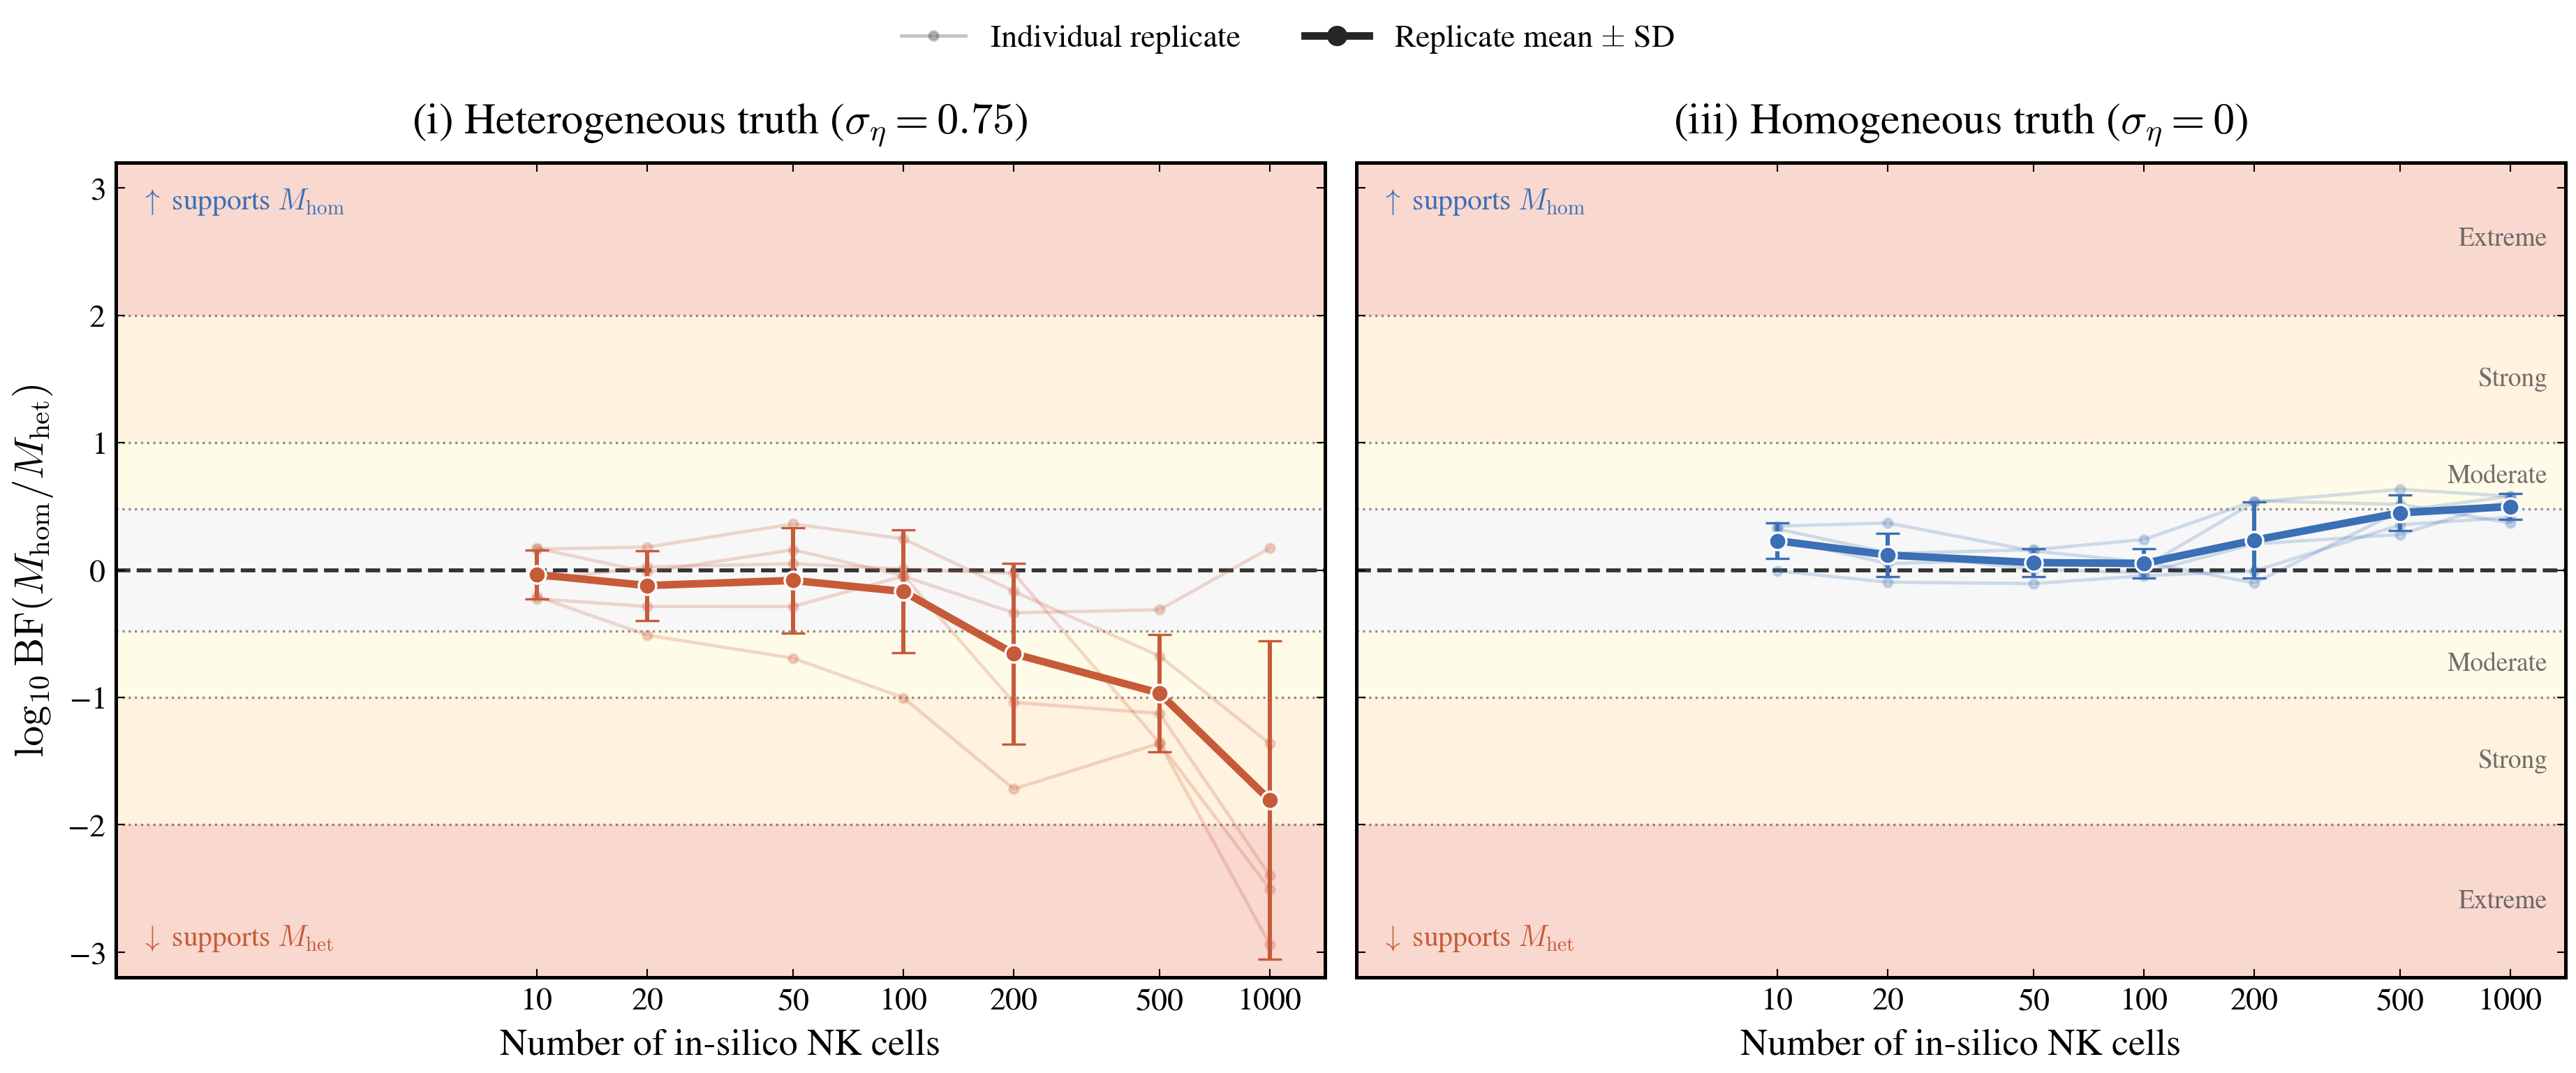

,format,path
0,svg,/Users/marsian/PhD_LifeSciRes/Barracuda/section_3/f...
1,png,/Users/marsian/PhD_LifeSciRes/Barracuda/section_3/f...


In [6]:
fig, axes = plot_pairwise_bf_trajectories(pairwise_df)

figure_stem = FIGURE_ROOT / "bf_homogeneous_vs_heterogeneous_vs_sample_size"
figure_paths = {
    "svg": figure_stem.with_suffix(".svg"),
    "png": figure_stem.with_suffix(".png"),
}
fig.savefig(figure_paths["svg"], bbox_inches="tight", transparent=True)
fig.savefig(figure_paths["png"], bbox_inches="tight", dpi=300, facecolor="white")
plt.show()

display(pd.DataFrame({"format": figure_paths.keys(), "path": [str(path) for path in figure_paths.values()]}))
